# BWM 最好–最差權重法：計算原理、數學推導與 Python 實作

本 Notebook 以「BWM 計算原理與數學推導教材」為藍本，將原本的 Markdown 教材整理成可執行的 Jupyter Notebook。

本教材分成三個部分：

1. BWM 的基本概念與數學推導。
2. Vanilla 建模版本：手動建立 BWM 線性規劃模型，並用 Python 函式完整呈現限制式。
3. 套件求解版本：使用 `scipy.optimize.linprog` 作為通用最佳化求解器，處理 BWM 權重估計問題。

> 說明：BWM 本質上是最佳化問題。相較於 AHP 常見專門套件，BWM 在 Python 中較常見的作法是自行建立模型，再交由通用最佳化工具求解。


## 0. 環境設定

本 Notebook 使用下列套件：

- `numpy`：矩陣與數值運算。
- `pandas`：表格整理。
- `scipy`：線性規劃求解。
- `matplotlib`：權重視覺化。

若尚未安裝，可執行：

```python
%pip install numpy pandas scipy matplotlib
```


以下內容保留原始教材的主要章節，並轉換為 Notebook 的 Markdown 說明。

# BWM 計算原理與數學推導教材

## 1. BWM 是什麼？

最好–最差權重法（Best–Worst Method, BWM）是 Rezaei（2015, 2016）提出的一種多準則決策方法，主要用來估計各項評估準則的權重。

BWM 的核心想法是：

> 先找出所有準則中「最重要」與「最不重要」的準則，再透過少量成對比較推估各準則權重。

相較於 AHP 需要大量兩兩比較，BWM 的問卷負擔較低，因此較適合用於一般消費者填答，或準則數量較多的研究情境。

以智慧型手錶選購為例，消費者可能會考量價格、電池續航力、健康監測功能、品牌信任度與外觀設計等因素。BWM 可以協助研究者判斷這些因素各自的重要程度。

---

## 2. 建立準則集合

在進行 BWM 分析前，必須先定義待評估的準則集合：

$$
C=\{c_1,c_2,\ldots,c_n\}
$$

其中，$c_j$ 表示第 $j$ 個準則，$n$ 表示準則總數。

例如，若研究智慧型手錶選購因素，可以設定：

$$
C=\{c_1,c_2,c_3,c_4,c_5\}
$$

其中：

$$
c_1=\text{價格}
$$

$$
c_2=\text{電池續航力}
$$

$$
c_3=\text{健康監測功能}
$$

$$
c_4=\text{品牌信任度}
$$

$$
c_5=\text{外觀設計}
$$

此時共有 5 個準則，因此：

$$
n=5
$$

---

## 3. 選出最好準則與最差準則

BWM 的第一個步驟，是請受測者或專家從所有準則中選出：

- 最好準則（Best criterion）：最重要的準則，記為 $c_B$
- 最差準則（Worst criterion）：最不重要的準則，記為 $c_W$

例如，某位消費者認為：

$$
c_B=c_3=\text{健康監測功能}
$$

$$
c_W=c_5=\text{外觀設計}
$$

意思是：在這位消費者心中，健康監測功能是最重要的智慧型手錶選購因素，而外觀設計是相對最不重要的因素。

---

## 4. 最好準則相對於其他準則的重要程度向量

接著，受測者需要使用 1–9 等級尺度，評估最好準則 $c_B$ 相對於各準則 $c_j$ 的重要程度。

尺度意義如下：

| 數值 | 意義 |
|---|---|
| 1 | 同等重要 |
| 3 | 稍微重要 |
| 5 | 明顯重要 |
| 7 | 非常重要 |
| 9 | 極端重要 |

這組比較結果形成向量：

$$
A_B=(a_{B1},a_{B2},\ldots,a_{Bn})
$$

其中，$a_{Bj}$ 表示最好準則 $c_B$ 相對於第 $j$ 個準則 $c_j$ 的重要程度。

以前述智慧型手錶例子來說，若最好準則為健康監測功能，且受測者填答如下：

$$
A_B=(5,3,1,4,7)
$$

則其意義為：

$$
a_{B1}=5
$$

表示健康監測功能相對於價格的重要程度為 5。

$$
a_{B2}=3
$$

表示健康監測功能相對於電池續航力的重要程度為 3。

$$
a_{B3}=1
$$

表示健康監測功能相對於自己，重要程度相同，因此為 1。

$$
a_{B4}=4
$$

表示健康監測功能相對於品牌信任度的重要程度為 4。

$$
a_{B5}=7
$$

表示健康監測功能相對於外觀設計的重要程度為 7。

需要注意的是，BWM 的 1–9 尺度主要是偏好強度，不一定是精確的數學倍數。例如填寫 5，較精確的意思是「明顯較重要」，而不是嚴格表示剛好重要 5.000 倍。

---

## 5. 其他準則相對於最差準則的重要程度向量

BWM 的第二組比較，是請受測者評估各準則 $c_j$ 相對於最差準則 $c_W$ 的重要程度，並形成向量：

$$
A_W=(a_{1W},a_{2W},\ldots,a_{nW})^T
$$

其中，$a_{jW}$ 表示第 $j$ 個準則 $c_j$ 相對於最差準則 $c_W$ 的重要程度。

延續前例，若最差準則為外觀設計，受測者可能填答：

$$
A_W=
\begin{bmatrix}
3\\
5\\
7\\
4\\
1
\end{bmatrix}
$$

其意義為：

$$
a_{1W}=3
$$

表示價格相對於外觀設計的重要程度為 3。

$$
a_{2W}=5
$$

表示電池續航力相對於外觀設計的重要程度為 5。

$$
a_{3W}=7
$$

表示健康監測功能相對於外觀設計的重要程度為 7。

$$
a_{4W}=4
$$

表示品牌信任度相對於外觀設計的重要程度為 4。

$$
a_{5W}=1
$$

表示外觀設計相對於自己，重要程度相同，因此為 1。

---

## 6. 權重向量的基本概念

假設各準則的權重向量為：

$$
w=(w_1,w_2,\ldots,w_n)
$$

其中，$w_j$ 表示第 $j$ 個準則的權重。

權重需滿足兩個基本條件：

$$
\sum_{j=1}^{n}w_j=1
$$

以及：

$$
w_j\geq 0,\quad \forall j
$$

也就是說，所有準則權重加總必須為 1，且每個準則權重不可為負數。

以智慧型手錶例子來說，若最後得到：

$$
w=(0.18,0.24,0.36,0.14,0.08)
$$

表示：

- 價格權重為 0.18
- 電池續航力權重為 0.24
- 健康監測功能權重為 0.36
- 品牌信任度權重為 0.14
- 外觀設計權重為 0.08

---

## 7. BWM 的理想權重比例關係

BWM 的核心是希望推估出來的權重比例，能盡量接近受測者填寫的比較值。

第一，最好準則相對於其他準則的權重比例，理想上應滿足：

$$
\frac{w_B}{w_j}\approx a_{Bj}
$$

其中，$w_B$ 表示最好準則的權重，$w_j$ 表示第 $j$ 個準則的權重。

例如，若健康監測功能是最好準則，且它相對於價格的重要程度為 5，則理想上：

$$
\frac{w_{\text{健康監測}}}{w_{\text{價格}}}\approx 5
$$

第二，其他準則相對於最差準則的權重比例，理想上應滿足：

$$
\frac{w_j}{w_W}\approx a_{jW}
$$

其中，$w_W$ 表示最差準則的權重。

例如，若外觀設計是最差準則，且價格相對於外觀設計的重要程度為 3，則理想上：

$$
\frac{w_{\text{價格}}}{w_{\text{外觀設計}}}\approx 3
$$

---

## 8. 為什麼需要最佳化模型？

實際上，受測者的判斷通常不會完全一致，因此不可能讓所有比例都完全等於填答數值。

例如，受測者可能同時填寫：

$$
a_{B1}=5
$$

表示健康監測功能相對於價格的重要程度為 5。

又填寫：

$$
a_{1W}=3
$$

表示價格相對於外觀設計的重要程度為 3。

如果完全依照比例推論，健康監測功能相對於外觀設計的重要程度應接近：

$$
5\times 3=15
$$

但 BWM 的尺度最大通常為 9，而且受測者可能直接填寫：

$$
a_{BW}=7
$$

這表示判斷之間可能存在一定程度的不一致。因此，BWM 不要求所有比例完全相等，而是透過最佳化方法尋找一組「整體偏差最小」的權重。

---

## 9. 最大偏差最小化模型

Rezaei（2015）提出最大偏差最小化的概念。其核心是：找出一組權重，使下列兩類偏差都盡量小。

第一類偏差為：

$$
\left|\frac{w_B}{w_j}-a_{Bj}\right|
$$

第二類偏差為：

$$
\left|\frac{w_j}{w_W}-a_{jW}\right|
$$

BWM 希望讓所有比較中的最大偏差最小。因此可建立非線性模型：

$$
\min \xi
$$

限制條件為：

$$
\left|\frac{w_B}{w_j}-a_{Bj}\right|\leq \xi,\quad \forall j
$$

$$
\left|\frac{w_j}{w_W}-a_{jW}\right|\leq \xi,\quad \forall j
$$

$$
\sum_{j=1}^{n}w_j=1
$$

$$
w_j\geq 0,\quad \forall j
$$

其中，$\xi$ 表示最大偏差值。$\xi$ 越小，代表推估出的權重越符合受測者原本填寫的比較判斷。

白話來說，BWM 不是只讓某一題比較很準，而是希望整體比較中最大的誤差也能被壓到最小。

---

## 10. Rezaei（2016）的線性化模型概念

Rezaei（2016）進一步將 BWM 模型改寫成較容易求解的線性形式。其思路是將比例關係轉換為乘法形式。

原本希望：

$$
\frac{w_B}{w_j}\approx a_{Bj}
$$

可改寫為：

$$
w_B\approx a_{Bj}w_j
$$

因此偏差可表示為：

$$
|w_B-a_{Bj}w_j|
$$

同理，原本希望：

$$
\frac{w_j}{w_W}\approx a_{jW}
$$

可改寫為：

$$
w_j\approx a_{jW}w_W
$$

因此偏差可表示為：

$$
|w_j-a_{jW}w_W|
$$

線性化後的模型可表示為：

$$
\min \xi
$$

限制條件為：

$$
|w_B-a_{Bj}w_j|\leq \xi,\quad \forall j
$$

$$
|w_j-a_{jW}w_W|\leq \xi,\quad \forall j
$$

$$
\sum_{j=1}^{n}w_j=1
$$

$$
w_j\geq 0,\quad \forall j
$$

這裡的 $\xi$ 仍然代表最大偏差。模型的目標仍是尋找一組權重，使所有比較關係中的最大偏差最小化。

---

## 11. 以智慧型手錶為例說明計算邏輯

假設有五個準則：

$$
C=\{\text{價格},\text{續航力},\text{健康監測},\text{品牌},\text{外觀}\}
$$

最好準則為：

$$
c_B=\text{健康監測}
$$

最差準則為：

$$
c_W=\text{外觀}
$$

受測者填寫：

$$
A_B=(5,3,1,4,7)
$$

以及：

$$
A_W=
\begin{bmatrix}
3\\
5\\
7\\
4\\
1
\end{bmatrix}
$$

則 BWM 會尋找一組權重：

$$
w=(w_1,w_2,w_3,w_4,w_5)
$$

使下列關係盡量成立：

$$
\frac{w_3}{w_1}\approx 5
$$

$$
\frac{w_3}{w_2}\approx 3
$$

$$
\frac{w_3}{w_3}=1
$$

$$
\frac{w_3}{w_4}\approx 4
$$

$$
\frac{w_3}{w_5}\approx 7
$$

同時也要使：

$$
\frac{w_1}{w_5}\approx 3
$$

$$
\frac{w_2}{w_5}\approx 5
$$

$$
\frac{w_3}{w_5}\approx 7
$$

$$
\frac{w_4}{w_5}\approx 4
$$

$$
\frac{w_5}{w_5}=1
$$

最後還必須滿足：

$$
w_1+w_2+w_3+w_4+w_5=1
$$

透過最佳化計算，可以得到一組最符合受測者判斷的權重。

---

## 12. BWM 一致性檢定

BWM 也有一致性檢定，用來判斷受測者或專家的填答是否合理。

其中，$a_{BW}$ 表示最好準則 $c_B$ 相對於最差準則 $c_W$ 的直接評分。

例如：

$$
a_{BW}=7
$$

表示受測者認為最好準則相對於最差準則的重要程度為 7。

然而，BWM 會進一步檢查其他填答是否與此邏輯大致一致。若受測者填答前後差異太大，表示判斷可能不穩定。

在最佳化模型求解後，會得到最佳最大偏差值：

$$
\xi^*
$$

其中，$\xi^*$ 可理解為在目前這組填答下，權重推估後仍無法消除的最大誤差。

Rezaei（2016）根據不同的 $a_{BW}$ 值，提供對應的一致性指標（Consistency Index, CI）。接著可計算一致性比率（Consistency Ratio, CR）：

$$
CR=\frac{\xi^*}{CI}
$$

其中：

- $CR$：一致性比率
- $\xi^*$：最佳化模型求得的最大偏差值
- $CI$：依據 $a_{BW}$ 查表得到的一致性指標

$CR$ 越小，表示填答越一致；$CR$ 越大，表示填答前後矛盾越明顯。

例如，若最佳化模型求得：

$$
\xi^*=0.20
$$

且當 $a_{BW}=7$ 時，查表得到：

$$
CI=3.73
$$

則：

$$
CR=\frac{0.20}{3.73}\approx 0.054
$$

此結果表示一致性良好。

---

## 13. BWM 的整體流程整理

BWM 的計算流程可整理如下：

1. 建立評估準則集合 $C=\{c_1,c_2,\ldots,c_n\}$。
2. 請受測者選出最好準則 $c_B$ 與最差準則 $c_W$。
3. 使用 1–9 尺度評估最好準則相對於其他準則的重要程度，形成 $A_B$。
4. 使用 1–9 尺度評估其他準則相對於最差準則的重要程度，形成 $A_W$。
5. 建立權重向量 $w=(w_1,w_2,\ldots,w_n)$。
6. 透過最大偏差最小化模型求得各準則權重。
7. 根據 $\xi^*$ 與 $CI$ 計算 $CR$，檢查填答一致性。
8. 若一致性可接受，則使用該權重進行後續分析；若一致性不佳，則需檢查或修正填答資料。

---

## 14. BWM 的研究應用意義

在智慧型手錶研究中，BWM 可用來分析消費者對不同選購準則的偏好程度。例如研究者可以透過 BWM 得知消費者是否更重視健康監測功能、電池續航力、價格、品牌信任度或外觀設計。

相較於 AHP，BWM 的優點在於比較題數較少，能降低受測者填答負擔。同時，BWM 仍保留成對比較的邏輯，能夠將主觀偏好轉換為量化權重，因此適合用於消費者偏好分析與產品選擇研究。

若再結合 LLM 對半結構式訪談內容進行語意分析，則可進一步比較「消費者問卷中明確表達的偏好」與「自然語言回答中呈現的隱性偏好」是否一致，進而提升研究的完整性與解釋力。


# 15. Python 實作一：Vanilla 建模版本

這一節的重點不是直接呼叫現成的 BWM 函式，而是從 BWM 的線性化模型出發，手動建立目標函數與限制式。

教材中的範例為五個準則：

- 價格
- 電池續航力
- 健康監測功能
- 品牌信任度
- 外觀設計

最好準則為：

$$
c_B=\text{健康監測功能}
$$

最差準則為：

$$
c_W=\text{外觀設計}
$$

最好準則相對於其他準則的重要程度向量為：

$$
A_B=(5,3,1,4,7)
$$

其他準則相對於最差準則的重要程度向量為：

$$
A_W=(3,5,7,4,1)^T
$$


In [1]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=6, suppress=True)


In [2]:
criteria = ["價格", "電池續航力", "健康監測功能", "品牌信任度", "外觀設計"]

best = "健康監測功能"
worst = "外觀設計"

best_index = criteria.index(best)
worst_index = criteria.index(worst)

# A_B: 最好準則相對於其他準則的重要程度
A_B = np.array([5, 3, 1, 4, 7], dtype=float)

# A_W: 其他準則相對於最差準則的重要程度
A_W = np.array([3, 5, 7, 4, 1], dtype=float)

pd.DataFrame({
    "準則": criteria,
    "A_B：Best 相對於該準則": A_B,
    "A_W：該準則相對於 Worst": A_W
})


,準則,A_B：Best 相對於該準則,A_W：該準則相對於 Worst
0,價格,5.0,3.0
1,電池續航力,3.0,5.0
2,健康監測功能,1.0,7.0
3,品牌信任度,4.0,4.0
4,外觀設計,7.0,1.0


## 15.1 將 BWM 線性模型轉為程式可處理的形式

BWM 線性化模型為：

$$
\min \xi
$$

限制條件為：

$$
|w_B-a_{Bj}w_j|\leq \xi,\quad \forall j
$$

$$
|w_j-a_{jW}w_W|\leq \xi,\quad \forall j
$$

$$
\sum_{j=1}^{n}w_j=1
$$

$$
w_j\geq 0,\quad \forall j
$$

由於線性規劃不能直接處理絕對值，因此需要把每一個絕對值限制式拆成兩條不等式。

對於第一類限制式：

$$
|w_B-a_{Bj}w_j|\leq \xi
$$

可拆成：

$$
w_B-a_{Bj}w_j-\xi\leq 0
$$

$$
-w_B+a_{Bj}w_j-\xi\leq 0
$$

對於第二類限制式：

$$
|w_j-a_{jW}w_W|\leq \xi
$$

可拆成：

$$
w_j-a_{jW}w_W-\xi\leq 0
$$

$$
-w_j+a_{jW}w_W-\xi\leq 0
$$

程式中，我們把變數設為：

$$
x=(w_1,w_2,\ldots,w_n,\xi)
$$

也就是前 $n$ 個變數是權重，最後一個變數是最大偏差值 $\xi$。


In [3]:
def build_bwm_linear_program(A_B, A_W, best_index, worst_index):
    """手動建立 BWM 線性規劃模型。

    變數排列：
    x = [w_1, w_2, ..., w_n, xi]

    回傳：
    c: 目標函數係數
    A_ub, b_ub: 不等式限制 A_ub @ x <= b_ub
    A_eq, b_eq: 等式限制 A_eq @ x == b_eq
    bounds: 變數上下界
    """
    A_B = np.asarray(A_B, dtype=float)
    A_W = np.asarray(A_W, dtype=float)
    n = len(A_B)
    xi_index = n

    # 目標：min xi
    c = np.zeros(n + 1)
    c[xi_index] = 1

    A_ub = []
    b_ub = []

    for j in range(n):
        # |w_B - a_Bj * w_j| <= xi
        row = np.zeros(n + 1)
        row[best_index] = 1
        row[j] -= A_B[j]
        row[xi_index] = -1
        A_ub.append(row)
        b_ub.append(0)

        row = np.zeros(n + 1)
        row[best_index] = -1
        row[j] += A_B[j]
        row[xi_index] = -1
        A_ub.append(row)
        b_ub.append(0)

        # |w_j - a_jW * w_W| <= xi
        row = np.zeros(n + 1)
        row[j] = 1
        row[worst_index] -= A_W[j]
        row[xi_index] = -1
        A_ub.append(row)
        b_ub.append(0)

        row = np.zeros(n + 1)
        row[j] = -1
        row[worst_index] += A_W[j]
        row[xi_index] = -1
        A_ub.append(row)
        b_ub.append(0)

    # 權重總和 = 1
    A_eq = np.zeros((1, n + 1))
    A_eq[0, :n] = 1
    b_eq = np.array([1.0])

    # w_j >= 0, xi >= 0
    bounds = [(0, None) for _ in range(n + 1)]

    return c, np.array(A_ub), np.array(b_ub), A_eq, b_eq, bounds

c, A_ub, b_ub, A_eq, b_eq, bounds = build_bwm_linear_program(
    A_B=A_B,
    A_W=A_W,
    best_index=best_index,
    worst_index=worst_index
)

print("目標函數係數 c：")
print(c)

print("\n不等式限制矩陣 A_ub 形狀：", A_ub.shape)
print("等式限制矩陣 A_eq 形狀：", A_eq.shape)


目標函數係數 c：
[0. 0. 0. 0. 0. 1.]

不等式限制矩陣 A_ub 形狀： (20, 6)
等式限制矩陣 A_eq 形狀： (1, 6)


# 16. Python 實作二：使用通用最佳化套件求解

這一節使用 `scipy.optimize.linprog` 進行線性規劃求解。

這不是 BWM 專屬套件，而是通用最佳化套件。對 BWM 這類可以被線性化的模型而言，這種做法通常比依賴不穩定或冷門的專門套件更可控。

線性規劃問題的一般形式為：

$$
\min c^Tx
$$

subject to:

$$
A_{ub}x\leq b_{ub}
$$

$$
A_{eq}x=b_{eq}
$$

在本例中：

- $x=(w_1,w_2,w_3,w_4,w_5,\xi)$
- 目標是最小化 $\xi$
- 權重總和必須等於 1
- 所有權重與 $\xi$ 皆不可為負數


In [4]:
from scipy.optimize import linprog

result = linprog(
    c=c,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs"
)

print("是否成功求解：", result.success)
print("求解訊息：", result.message)

solution = result.x
weights = solution[:-1]
xi_star = solution[-1]

bwm_result = pd.DataFrame({
    "準則": criteria,
    "權重": weights
}).sort_values("權重", ascending=False)

print("\n最佳最大偏差 xi* =", xi_star)
bwm_result


是否成功求解： True
求解訊息： Optimization terminated successfully. (HiGHS Status 7: Optimal)

最佳最大偏差 xi* = 0.09096077316657196


,準則,權重
2,健康監測功能,0.488914
1,電池續航力,0.193292
3,品牌信任度,0.144969
0,價格,0.115975
4,外觀設計,0.056850


## 16.1 檢查權重比例是否接近原始判斷

求得權重後，可以檢查：

$$
\frac{w_B}{w_j}
$$

是否接近 $a_{Bj}$，以及：

$$
\frac{w_j}{w_W}
$$

是否接近 $a_{jW}$。

這不是重新求解，而是用來理解模型結果是否合理。


In [5]:
w_B = weights[best_index]
w_W = weights[worst_index]

check_table = pd.DataFrame({
    "準則": criteria,
    "A_B 原始判斷": A_B,
    "w_B / w_j": w_B / weights,
    "A_W 原始判斷": A_W,
    "w_j / w_W": weights / w_W
})

check_table


,準則,A_B 原始判斷,w_B / w_j,A_W 原始判斷,w_j / w_W
0,價格,5.0,4.215686,3.0,2.04
1,電池續航力,3.0,2.529412,5.0,3.40
2,健康監測功能,1.0,1.000000,7.0,8.60
3,品牌信任度,4.0,3.372549,4.0,2.55
4,外觀設計,7.0,8.600000,1.0,1.00


## 16.2 BWM 一致性比率 CR

教材中提到，BWM 可根據最佳最大偏差值 $\xi^*$ 與一致性指標 $CI$ 計算一致性比率：

$$
CR=\frac{\xi^*}{CI}
$$

其中 $CI$ 需要根據 $a_{BW}$ 查表。

以下使用常見 Rezaei 線性 BWM 的 CI 參考表：

| $a_{BW}$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| CI | 0.00 | 0.44 | 1.00 | 1.63 | 2.30 | 3.00 | 3.73 | 4.47 | 5.23 |

本例中 $a_{BW}=7$，因此 $CI=3.73$。


In [6]:
BWM_CI_TABLE = {
    1: 0.00,
    2: 0.44,
    3: 1.00,
    4: 1.63,
    5: 2.30,
    6: 3.00,
    7: 3.73,
    8: 4.47,
    9: 5.23
}

a_BW = int(A_B[worst_index])
ci_bwm = BWM_CI_TABLE[a_BW]

cr_bwm = 0 if ci_bwm == 0 else xi_star / ci_bwm

pd.DataFrame({
    "項目": ["a_BW", "xi*", "CI", "CR", "一致性判斷"],
    "結果": [a_BW, xi_star, ci_bwm, cr_bwm, "良好" if cr_bwm < 0.10 else "需檢查"]
})


,項目,結果
0,a_BW,7
1,xi*,0.090961
2,CI,3.73
3,CR,0.024386
4,一致性判斷,良好


## 16.3 權重視覺化

下圖呈現 BWM 求得的準則權重。權重越高，代表該準則在整體決策中的相對重要性越高。


/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22806 (\N{CJK UNIFIED IDEOGRAPH-5916}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35264 (\N{CJK UNIFIED IDEOGRAPH-89C0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35373 (\N{CJK UNIFIED IDEOGRAPH-8A2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35336 (\N{CJK UNIFIED IDEOGRAPH-8A08}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/minicon

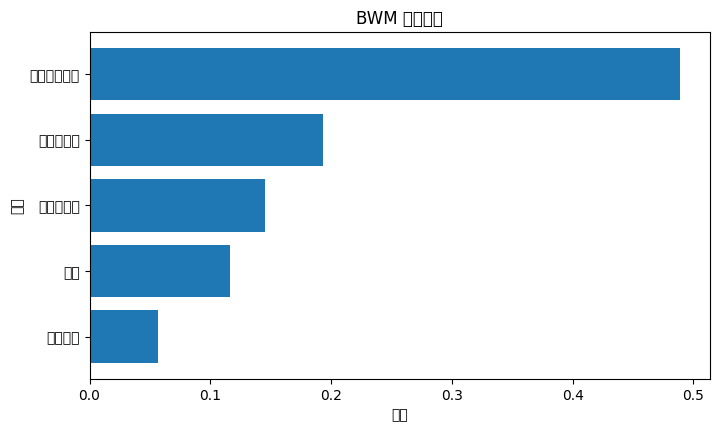

In [7]:
import matplotlib.pyplot as plt

plot_df = bwm_result.sort_values("權重", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["準則"], plot_df["權重"])
plt.xlabel("權重")
plt.ylabel("準則")
plt.title("BWM 準則權重")
plt.show()


# 17. 關於 BWM 專門套件的說明

和 AHP 相比，BWM 在 Python 生態中較少有穩定、廣泛使用、介面一致的專門套件。因此，本 Notebook 不把某個冷門 BWM 專門套件設為必要依賴。

對一般研究與教學而言，較穩定的做法是：

1. 自行明確建立 BWM 的線性化模型。
2. 使用 `scipy.optimize.linprog`、`cvxpy` 或其他通用最佳化套件求解。
3. 清楚保留輸入向量、限制式、權重結果、$\xi^*$ 與 CR。

若後續要處理更複雜的 BWM 變體，例如 nonlinear BWM、fuzzy BWM、interval BWM 或 group BWM，則可以再考慮使用 `cvxpy` 建模，或依照特定論文模型自行建立最佳化限制式。


## 17.1 可選：使用 CVXPY 建模

`cvxpy` 是另一種通用最佳化建模工具。它的優點是模型寫法更接近數學式；缺點是需要額外安裝，且不同求解器在環境設定上可能較複雜。

若尚未安裝，可執行：

```python
%pip install cvxpy
```

以下程式碼保留為可選範例。


In [8]:
# 如需使用 CVXPY，可取消註解後執行。
# %pip install cvxpy

try:
    import cvxpy as cp

    n = len(criteria)
    w = cp.Variable(n, nonneg=True)
    xi = cp.Variable(nonneg=True)

    constraints = [cp.sum(w) == 1]

    for j in range(n):
        constraints.append(cp.abs(w[best_index] - A_B[j] * w[j]) <= xi)
        constraints.append(cp.abs(w[j] - A_W[j] * w[worst_index]) <= xi)

    problem = cp.Problem(cp.Minimize(xi), constraints)
    problem.solve()

    cvxpy_result = pd.DataFrame({
        "準則": criteria,
        "CVXPY 權重": w.value
    }).sort_values("CVXPY 權重", ascending=False)

    print("xi* =", xi.value)
    display(cvxpy_result)

except ImportError:
    print("尚未安裝 cvxpy。若要使用此版本，請先執行：%pip install cvxpy")


尚未安裝 cvxpy。若要使用此版本，請先執行：%pip install cvxpy


# 18. 延伸：多位專家 BWM 資料整合

若有多位專家填寫 BWM 問卷，常見作法是先將每位專家的 $A_B$ 與 $A_W$ 用幾何平均法整合，再進行 BWM 求解。

幾何平均適合比例尺度資料，因為 BWM 的 1–9 尺度本質上描述的是相對偏好強度。


In [9]:
def geometric_mean_across_experts(arrays):
    """對多位專家的比較向量取幾何平均。"""
    stacked = np.asarray(arrays, dtype=float)
    return np.prod(stacked, axis=0) ** (1 / stacked.shape[0])

# 假設三位專家的填答如下
expert_A_B = [
    [5, 3, 1, 4, 7],
    [4, 3, 1, 5, 8],
    [5, 4, 1, 4, 7],
]

expert_A_W = [
    [3, 5, 7, 4, 1],
    [3, 4, 8, 5, 1],
    [4, 5, 7, 4, 1],
]

group_A_B = geometric_mean_across_experts(expert_A_B)
group_A_W = geometric_mean_across_experts(expert_A_W)

pd.DataFrame({
    "準則": criteria,
    "整合後 A_B": group_A_B,
    "整合後 A_W": group_A_W
})


,準則,整合後 A_B,整合後 A_W
0,價格,4.641589,3.301927
1,電池續航力,3.301927,4.641589
2,健康監測功能,1.000000,7.318611
3,品牌信任度,4.308869,4.308869
4,外觀設計,7.318611,1.000000


In [10]:
c_g, A_ub_g, b_ub_g, A_eq_g, b_eq_g, bounds_g = build_bwm_linear_program(
    A_B=group_A_B,
    A_W=group_A_W,
    best_index=best_index,
    worst_index=worst_index
)

group_result = linprog(
    c=c_g,
    A_ub=A_ub_g,
    b_ub=b_ub_g,
    A_eq=A_eq_g,
    b_eq=b_eq_g,
    bounds=bounds_g,
    method="highs"
)

group_weights = group_result.x[:-1]
group_xi = group_result.x[-1]

pd.DataFrame({
    "準則": criteria,
    "群體 BWM 權重": group_weights
}).sort_values("群體 BWM 權重", ascending=False)


,準則,群體 BWM 權重
2,健康監測功能,0.498197
1,電池續航力,0.180436
3,品牌信任度,0.138270
0,價格,0.128358
4,外觀設計,0.054738


# 19. 小結

本 Notebook 將 BWM 的概念、數學推導與 Python 實作連接起來。

重點如下：

1. BWM 先選出最好準則與最差準則。
2. 受測者只需填寫兩組比較向量：$A_B$ 與 $A_W$。
3. BWM 透過最佳化模型尋找一組整體偏差最小的權重。
4. 線性化模型可將 BWM 寫成線性規劃問題。
5. `scipy.optimize.linprog` 是處理線性 BWM 的穩定做法。
6. 若要進一步研究 fuzzy BWM、interval BWM 或 nonlinear BWM，可改用 `cvxpy` 或依照特定論文模型自行建模。

在研究實務上，建議保留完整輸入向量、最佳化模型、權重結果與一致性檢定，避免只呈現最後權重而無法追溯判斷來源。
